<a href="https://colab.research.google.com/github/hmmnyamminji/DL/blob/main/day03_practice1_%ED%8D%BC%EC%85%89%ED%8A%B8%EB%A1%A0_XOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

plt.rcParams["axes.unicode_minus"] = False # 마이너스 부호 깨짐 방지 설정
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"

In [14]:
# 셀 1. 논리 게이트 데이터 - 입력 2개, 출력 1개
X = torch.tensor([[0.0,0.0],
                  [0.0,1.0],
                  [1.0,0.0],
                  [1.0,1.0]])

y_and = torch.tensor([[0.0],[0.0],[0.0],[1.0]]) # 둘 다 1일 때만 1
y_or = torch.tensor([[0.0],[1.0],[1.0],[1.0]]) # 하나라도 1이면 1
y_xor = torch.tensor([[0.0],[1.0],[1.0],[0.0]]) # 서로 다를 때만 1

print("입력 4가지:", X.tolist())
print("XOR 정답 :", y_xpr.flatten().tolist())

입력 4가지: [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]
XOR 정답 : [0.0, 1.0, 1.0, 0.0]


In [25]:
# 셀 2. 공동 도구 - 학습 함수와 결정경계 그리기
def train(model, y, epochs=3000, lr=0.1):
  loss_fn = nn.MSELoss()
  optimizer = torch.optim.SGD(model.parameters(), lr=lr)
  for epoch in range(epochs):
    y_pred = model(X)                   # 1)예측
    loss = loss_fn(y_pred, y)           # 2)손실
    optimizer.zero_grad()
    loss.backward()                     # 3)역전파
    optimizer.step()                    # 4) 갱신
  return loss.item()

def accuracy(model, y):
    with torch.no_grad():
        pred = (model(X) > 0.5).float()
        return (pred == y).float().mean().item()



In [26]:
# 셀 3. 단층 퍼셉트론 (뉴런 하나) - AND 와 OR 는 성공
for name, y in [("AND", y_and),("OR", y_or)]:
  single = nn.Sequential(nn.Linear(2,1),nn.Sigmoid()) # 선형 + 시그모이드 = 뉴런 하나
  train(single, y)
  print(f"{name:3s} | 정확도 {accuracy(single, y):.0%} | 예측 {(round(v,2) for v in single(X).flatten().tolist())}")

AND | 정확도 100% | 예측 <generator object <genexpr> at 0x7e38ec615c40>
OR  | 정확도 100% | 예측 <generator object <genexpr> at 0x7e38ec58f760>


In [27]:
# 셀 4. 다층 퍼셉트론 - 은닉층으로 XOR 해결
mip = nn.Sequential(
    nn.Linear(2,16), # 은닉층: 뉴런 16개
    nn.ReLU(),       # 비선형 활성화
    nn.Linear(16,1),
    nn.Sigmoid(),
)

final_loss = train(mip, y_xor)
print(f"\nMLP | 정확도 {accuracy(mip, y_xor):.0%} | 손실 {final_loss:.4f}")
print("예측", [round(v, 2) for v in mip(X).flatten().tolist()])


MLP | 정확도 100% | 손실 0.0016
예측 [0.04, 0.97, 0.95, 0.04]


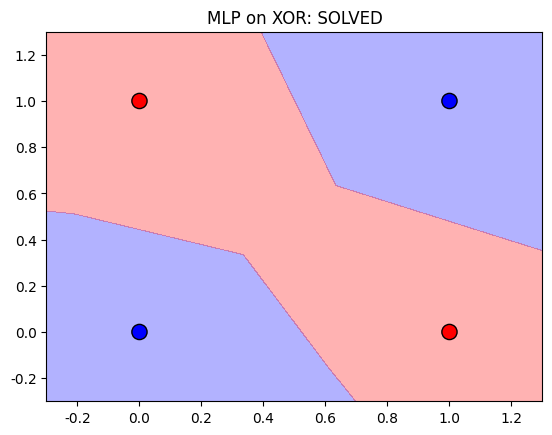

<Figure size 640x480 with 0 Axes>

In [28]:
# 모델이 평면을 어떻게 나누는지(결정경계) 색으로 표시
def plot_boundary(model, title, filename):
    xx, yy = torch.meshgrid(torch.linspace(-0.3,1.3,200),
                            torch.linspace(-0.3,1.3,200),indexing="xy")
    grid = torch.stack([xx.flatten(), yy.flatten()], dim=1)
    with torch.no_grad():
        zz = model(grid).reshape(xx.shape) #
    plt.contourf(xx, yy, zz, levels=[0,0.5,1], alpha=0.3, colors=["blue","red"]) # 결정 경계 영역 채우기
    plt.scatter(X[:,0], X[:,1],c=["blue","red","red","blue"], s=120, edgecolors="black") # XOR 기존 색: 0=파랑, 1=빨강
    plt.title(title)
    plt.savefig(filename)
    plt.show()
    plt.clf()

plot_boundary(mip, "MLP on XOR: SOLVED","plot2_xor.solved.png")